In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv(r"C:\Users\windows 10\Downloads\Flight_Booking - Flight_Booking.csv")

In [3]:
df

,Unnamed: 0,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955
...,...,...,...,...,...,...,...,...,...,...,...,...
300148,300148,Vistara,UK-822,Chennai,Morning,one,Evening,Hyderabad,Business,10.08,49,69265
300149,300149,Vistara,UK-826,Chennai,Afternoon,one,Night,Hyderabad,Business,10.42,49,77105
300150,300150,Vistara,UK-832,Chennai,Early_Morning,one,Night,Hyderabad,Business,13.83,49,79099
300151,300151,Vistara,UK-828,Chennai,Early_Morning,one,Evening,Hyderabad,Business,10.00,49,81585


The first column is the index so iam going to remove it:-

In [4]:
df = df.drop(columns =['Unnamed: 0'])

In [5]:
df

,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955
...,...,...,...,...,...,...,...,...,...,...,...
300148,Vistara,UK-822,Chennai,Morning,one,Evening,Hyderabad,Business,10.08,49,69265
300149,Vistara,UK-826,Chennai,Afternoon,one,Night,Hyderabad,Business,10.42,49,77105
300150,Vistara,UK-832,Chennai,Early_Morning,one,Night,Hyderabad,Business,13.83,49,79099
300151,Vistara,UK-828,Chennai,Early_Morning,one,Evening,Hyderabad,Business,10.00,49,81585


# Summery Of the Data:-

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300153 entries, 0 to 300152
Data columns (total 11 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   airline           300153 non-null  object 
 1   flight            300153 non-null  object 
 2   source_city       300153 non-null  object 
 3   departure_time    300153 non-null  object 
 4   stops             300153 non-null  object 
 5   arrival_time      300153 non-null  object 
 6   destination_city  300153 non-null  object 
 7   class             300153 non-null  object 
 8   duration          300153 non-null  float64
 9   days_left         300153 non-null  int64  
 10  price             300153 non-null  int64  
dtypes: float64(1), int64(2), object(8)
memory usage: 25.2+ MB


In [7]:
df.isna().sum()

airline             0
flight              0
source_city         0
departure_time      0
stops               0
arrival_time        0
destination_city    0
class               0
duration            0
days_left           0
price               0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(531)

In [9]:
df = df.drop_duplicates()

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df['airline'].value_counts()

airline
Vistara      127859
Air_India     80892
Indigo        42589
GO_FIRST      23173
AirAsia       16098
SpiceJet       9011
Name: count, dtype: int64

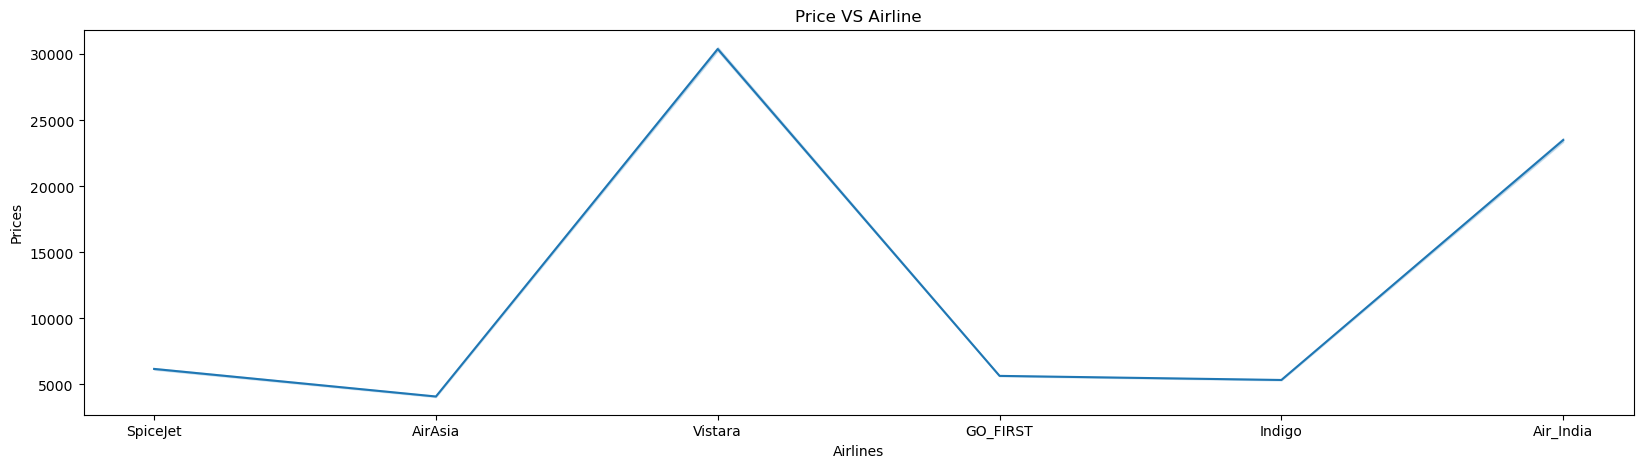

In [12]:
plt.figure(figsize = (20,5))
sns.lineplot(data = df, x= 'airline' , y = 'price')
plt.title('Price VS Airline')
plt.xlabel('Airlines')
plt.ylabel('Prices')
plt.show()

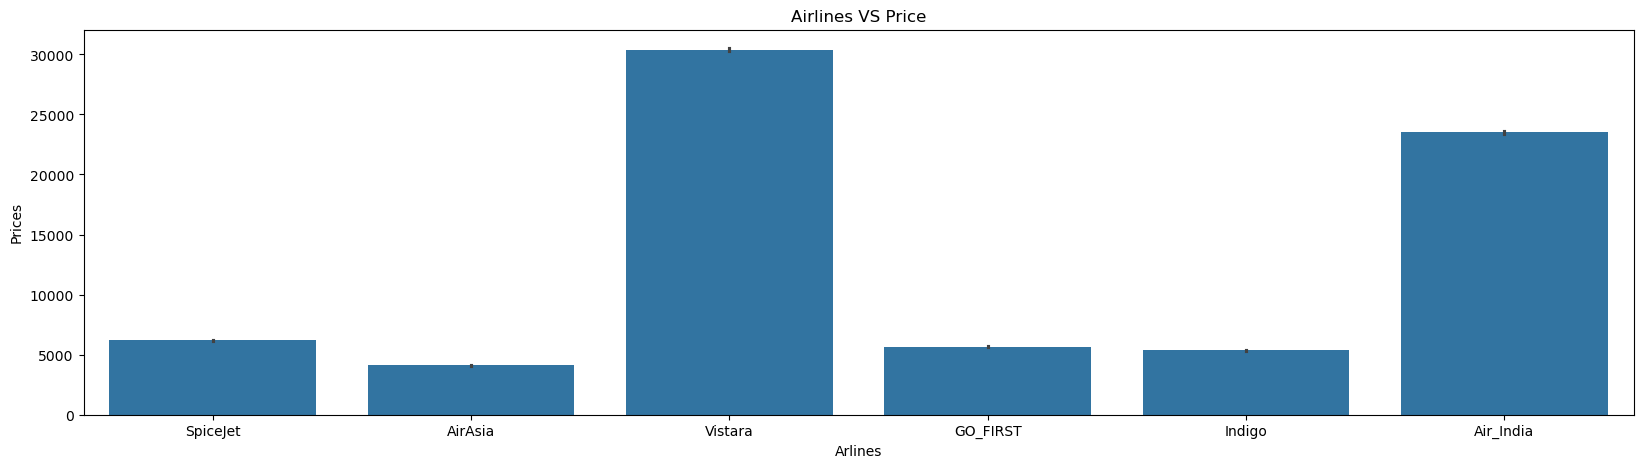

In [13]:
plt.figure(figsize = (20,5))
sns.barplot(data = df , x = 'airline' , y = 'price')
plt.title('Airlines VS Price')
plt.xlabel('Arlines')
plt.ylabel('Prices')
plt.show()
# Vistara and The Air_india is the most exprecive.

In [14]:
df['class'].value_counts()

class
Economy     206135
Business     93487
Name: count, dtype: int64

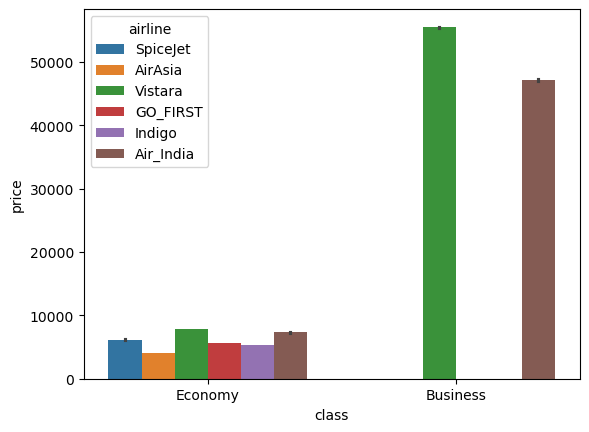

In [15]:
sns.barplot(data = df , x = 'class' , y= 'price' , hue = 'airline')
plt.show()

In [16]:
print(f"The Range Of Bussines Class:- {df[df['class'] == 'Business']['price'].min()}$ - {df[df['class'] == 'Business']['price'].max()}$")

The Range Of Bussines Class:- 12000$ - 123071$


In [17]:
print(f"The Range Of Economy Class:- {df[df['class'] == 'Economy']['price'].min()}$ - {df[df['class'] == 'Economy']['price'].max()}$")

The Range Of Economy Class:- 1105$ - 42349$


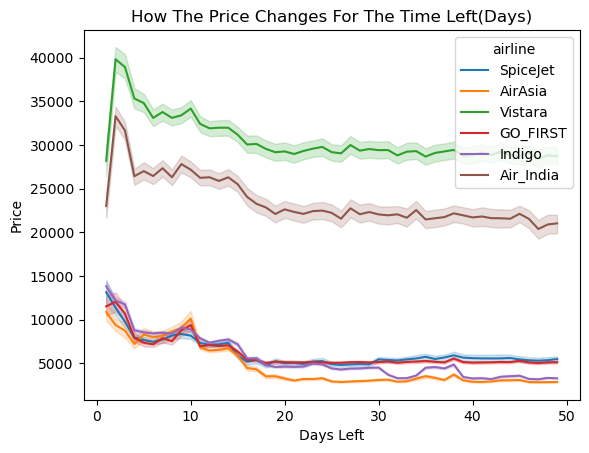

In [18]:
sns.lineplot(data = df , x = 'days_left', y = 'price' , hue = 'airline')
plt.title("How The Price Changes For The Time Left(Days)")
plt.xlabel('Days Left')
plt.ylabel('Price')
plt.show()

# Preprocessing:-

In [19]:
from sklearn.preprocessing import LabelEncoder

In [20]:
le = LabelEncoder()

In [21]:
df.columns

Index(['airline', 'flight', 'source_city', 'departure_time', 'stops',
       'arrival_time', 'destination_city', 'class', 'duration', 'days_left',
       'price'],
      dtype='object')

In [22]:
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = le.fit_transform(df[col])

C:\Users\windows 10\AppData\Local\Temp\ipykernel_3240\786133641.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[col] = le.fit_transform(df[col])
C:\Users\windows 10\AppData\Local\Temp\ipykernel_3240\786133641.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[col] = le.fit_transform(df[col])
C:\Users\windows 10\AppData\Local\Temp\ipykernel_3240\786133641.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = valu

In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 299622 entries, 0 to 300152
Data columns (total 11 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   airline           299622 non-null  int64  
 1   flight            299622 non-null  int64  
 2   source_city       299622 non-null  int64  
 3   departure_time    299622 non-null  int64  
 4   stops             299622 non-null  int64  
 5   arrival_time      299622 non-null  int64  
 6   destination_city  299622 non-null  int64  
 7   class             299622 non-null  int64  
 8   duration          299622 non-null  float64
 9   days_left         299622 non-null  int64  
 10  price             299622 non-null  int64  
dtypes: float64(1), int64(10)
memory usage: 27.4 MB


In [24]:
df.head(5)

,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,4,786,2,2,2,5,5,1,2.17,1,5953
1,4,765,2,1,2,4,5,1,2.33,1,5953
2,0,591,2,1,2,1,5,1,2.17,1,5956
3,5,937,2,4,2,0,5,1,2.25,1,5955
4,5,927,2,4,2,4,5,1,2.33,1,5955


# Splitting:-

In [25]:
x = df.drop(columns =['price'])

In [26]:
y = df['price']

In [27]:
x

,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left
0,4,786,2,2,2,5,5,1,2.17,1
1,4,765,2,1,2,4,5,1,2.33,1
2,0,591,2,1,2,1,5,1,2.17,1
3,5,937,2,4,2,0,5,1,2.25,1
4,5,927,2,4,2,4,5,1,2.33,1
...,...,...,...,...,...,...,...,...,...,...
300148,5,855,1,4,0,2,3,0,10.08,49
300149,5,859,1,0,0,5,3,0,10.42,49
300150,5,864,1,1,0,5,3,0,13.83,49
300151,5,861,1,1,0,2,3,0,10.00,49


In [28]:
y

0          5953
1          5953
2          5956
3          5955
4          5955
          ...  
300148    69265
300149    77105
300150    79099
300151    81585
300152    81585
Name: price, Length: 299622, dtype: int64

In [29]:
from sklearn.model_selection import train_test_split 

In [30]:
x_train , x_test , y_train , y_test = train_test_split(x,y,train_size = 0.8, random_state = 0)

In [31]:
x_train.shape

(239697, 10)

In [32]:
x_test.shape

(59925, 10)

# Model Building:-

In [33]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score

In [34]:
models = {
    'LR' : LinearRegression(),
    'DT' : DecisionTreeRegressor(),
    'RF' : RandomForestRegressor()
}

In [35]:
result = {}
for name , model in models.items():
    model.fit(x_train , y_train)
    model_pred = model.predict(x_test)

    score = r2_score(y_test , model_pred) * 100

    result[name] = score

In [36]:
result

{'LR': 90.45576967473336, 'DT': 98.25271376220702, 'RF': 98.97470956384845}

In [37]:
for model , score in result.items():
    print(f"The R2_score {score} for the Model {model}")

The R2_score 90.45576967473336 for the Model LR
The R2_score 98.25271376220702 for the Model DT
The R2_score 98.97470956384845 for the Model RF


# Visualization of the performance of each model:-

In [38]:
model_names = result.keys()

In [39]:
r2_scores = result.values()

C:\Users\windows 10\AppData\Local\Temp\ipykernel_3240\2981237856.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x = model_names , y = r2_scores ,palette = 'deep')


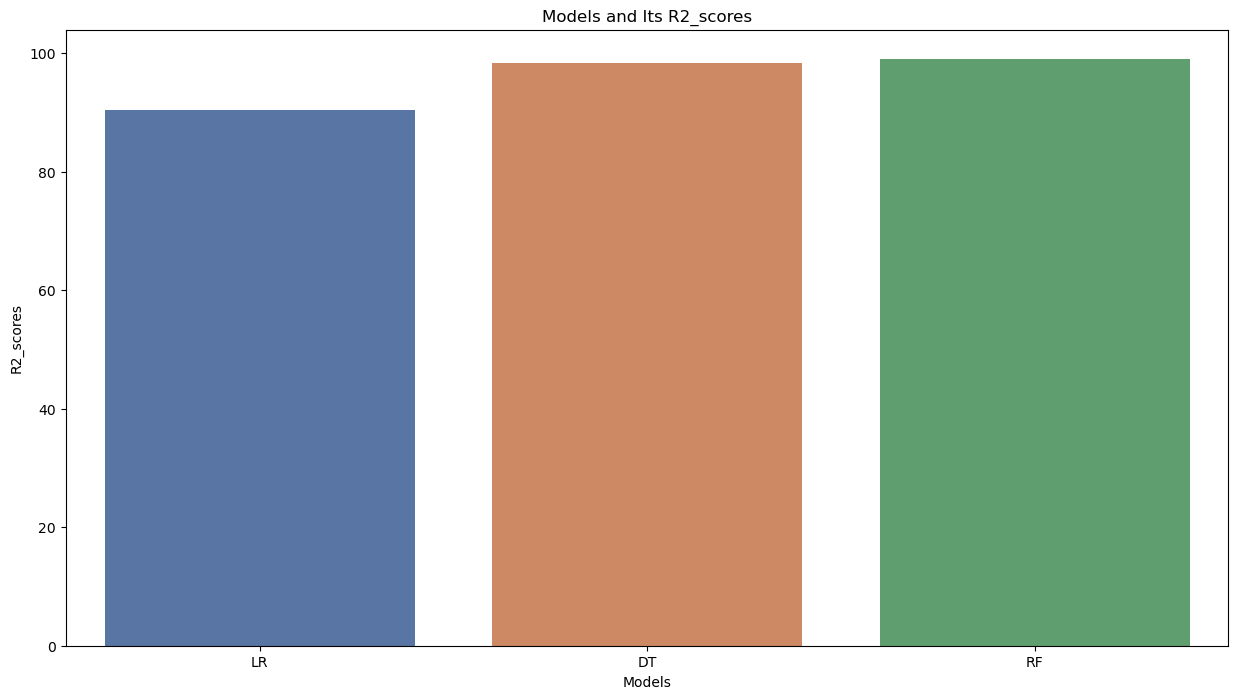

In [40]:
plt.figure(figsize =(15,8))
sns.barplot(x = model_names , y = r2_scores ,palette = 'deep')
plt.title("Models and Its R2_scores")
plt.xlabel('Models')
plt.ylabel('R2_scores')
plt.show()

# VIF:-

Now Lets Apply feture Selection:-


In [41]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [42]:
col_list = []
for col in df.columns:
    if col != 'price':  # bcaouse the price is the target:-
        col_list.append(col)

In [43]:
col_list

['airline',
 'flight',
 'source_city',
 'departure_time',
 'stops',
 'arrival_time',
 'destination_city',
 'class',
 'duration',
 'days_left']

In [44]:
x = df[col_list]

In [45]:
vif_data = pd.DataFrame()

In [46]:
vif_data['Features'] = x.columns

In [47]:
vif_data

,Features
0,airline
1,flight
2,source_city
3,departure_time
4,stops
5,arrival_time
6,destination_city
7,class
8,duration
9,days_left


In [48]:
x.columns

Index(['airline', 'flight', 'source_city', 'departure_time', 'stops',
       'arrival_time', 'destination_city', 'class', 'duration', 'days_left'],
      dtype='object')

In [49]:
x.values

array([[  4.  , 786.  ,   2.  , ...,   1.  ,   2.17,   1.  ],
       [  4.  , 765.  ,   2.  , ...,   1.  ,   2.33,   1.  ],
       [  0.  , 591.  ,   2.  , ...,   1.  ,   2.17,   1.  ],
       ...,
       [  5.  , 864.  ,   1.  , ...,   0.  ,  13.83,  49.  ],
       [  5.  , 861.  ,   1.  , ...,   0.  ,  10.  ,  49.  ],
       [  5.  , 855.  ,   1.  , ...,   0.  ,  10.08,  49.  ]])

In [50]:
vif_values = []

In [51]:
for i in range(len(x.columns)):
    vif = variance_inflation_factor(x.values,i)
    vif_values.append(vif)

In [52]:
vif_values

[np.float64(8.754316213188154),
 np.float64(7.650995525063621),
 np.float64(2.9297669076586583),
 np.float64(2.7823428955555216),
 np.float64(1.4222773675528138),
 np.float64(3.6883423915818425),
 np.float64(2.889500883883741),
 np.float64(2.8995641174891054),
 np.float64(4.2891631963543935),
 np.float64(3.9770376245436565)]

In [53]:
vif_data['vif_values'] = vif_values

In [54]:
vif_data

,Features,vif_values
0,airline,8.754316
1,flight,7.650996
2,source_city,2.929767
3,departure_time,2.782343
4,stops,1.422277
5,arrival_time,3.688342
6,destination_city,2.889501
7,class,2.899564
8,duration,4.289163
9,days_left,3.977038


as we know i fany value consistes of VIF value grater than "5" we remove them due to they are multicolinearity.

In [55]:
df = df.drop(columns =['airline'])

In [56]:
df

,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,786,2,2,2,5,5,1,2.17,1,5953
1,765,2,1,2,4,5,1,2.33,1,5953
2,591,2,1,2,1,5,1,2.17,1,5956
3,937,2,4,2,0,5,1,2.25,1,5955
4,927,2,4,2,4,5,1,2.33,1,5955
...,...,...,...,...,...,...,...,...,...,...
300148,855,1,4,0,2,3,0,10.08,49,69265
300149,859,1,0,0,5,3,0,10.42,49,77105
300150,864,1,1,0,5,3,0,13.83,49,79099
300151,861,1,1,0,2,3,0,10.00,49,81585


# Again Perform the VIF for the available columns:-

In [57]:
col_list2 = []
for col in df.columns:
    if col != 'price':
        col_list2.append(col)

In [58]:
col_list2

['flight',
 'source_city',
 'departure_time',
 'stops',
 'arrival_time',
 'destination_city',
 'class',
 'duration',
 'days_left']

In [59]:
x1 = df[col_list2]

In [60]:
x1

,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left
0,786,2,2,2,5,5,1,2.17,1
1,765,2,1,2,4,5,1,2.33,1
2,591,2,1,2,1,5,1,2.17,1
3,937,2,4,2,0,5,1,2.25,1
4,927,2,4,2,4,5,1,2.33,1
...,...,...,...,...,...,...,...,...,...
300148,855,1,4,0,2,3,0,10.08,49
300149,859,1,0,0,5,3,0,10.42,49
300150,864,1,1,0,5,3,0,13.83,49
300151,861,1,1,0,2,3,0,10.00,49


In [61]:
vif_data2 = pd.DataFrame()


In [62]:
vif_data2['Featuresss'] = x1.columns

In [63]:
vif_data2

,Featuresss
0,flight
1,source_city
2,departure_time
3,stops
4,arrival_time
5,destination_city
6,class
7,duration
8,days_left


In [64]:
x1


,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left
0,786,2,2,2,5,5,1,2.17,1
1,765,2,1,2,4,5,1,2.33,1
2,591,2,1,2,1,5,1,2.17,1
3,937,2,4,2,0,5,1,2.25,1
4,927,2,4,2,4,5,1,2.33,1
...,...,...,...,...,...,...,...,...,...
300148,855,1,4,0,2,3,0,10.08,49
300149,859,1,0,0,5,3,0,10.42,49
300150,864,1,1,0,5,3,0,13.83,49
300151,861,1,1,0,2,3,0,10.00,49


In [65]:
x1.values

array([[786.  ,   2.  ,   2.  , ...,   1.  ,   2.17,   1.  ],
       [765.  ,   2.  ,   1.  , ...,   1.  ,   2.33,   1.  ],
       [591.  ,   2.  ,   1.  , ...,   1.  ,   2.17,   1.  ],
       ...,
       [864.  ,   1.  ,   1.  , ...,   0.  ,  13.83,  49.  ],
       [861.  ,   1.  ,   1.  , ...,   0.  ,  10.  ,  49.  ],
       [855.  ,   1.  ,   4.  , ...,   0.  ,  10.08,  49.  ]])

In [66]:
vif_values_2 = []
for i in range(len(x1.columns)):
    vif2 = variance_inflation_factor(x.values , i)
    vif_values_2.append(vif2)
    

In [67]:
 vif_data2['vif_values_2'] = vif_values_2

In [68]:
vif_data2

,Featuresss,vif_values_2
0,flight,8.754316
1,source_city,7.650996
2,departure_time,2.929767
3,stops,2.782343
4,arrival_time,1.422277
5,destination_city,3.688342
6,class,2.889501
7,duration,2.899564
8,days_left,4.289163


as the valiue of flight is more then 5 but it is an important feature so iam keeping it:-

In [69]:
x1

,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left
0,786,2,2,2,5,5,1,2.17,1
1,765,2,1,2,4,5,1,2.33,1
2,591,2,1,2,1,5,1,2.17,1
3,937,2,4,2,0,5,1,2.25,1
4,927,2,4,2,4,5,1,2.33,1
...,...,...,...,...,...,...,...,...,...
300148,855,1,4,0,2,3,0,10.08,49
300149,859,1,0,0,5,3,0,10.42,49
300150,864,1,1,0,5,3,0,13.83,49
300151,861,1,1,0,2,3,0,10.00,49


In [71]:
y = df['price']

In [72]:
y

0          5953
1          5953
2          5956
3          5955
4          5955
          ...  
300148    69265
300149    77105
300150    79099
300151    81585
300152    81585
Name: price, Length: 299622, dtype: int64

In [73]:
x_train , x_test , y_train , y_test = train_test_split(x1 , y , train_size = 0.8 , random_state = 42)

# Model Building:-

In [74]:
models

{'LR': LinearRegression(),
 'DT': DecisionTreeRegressor(),
 'RF': RandomForestRegressor()}

In [75]:
result_vif = {}
for name , model in models.items():
    model.fit(x_train , y_train)
    model_pred = model.predict(x_test)
    score = r2_score(y_test ,model_pred )
    result_vif[name] = score


In [77]:
result_vif

{'LR': 0.9025314611595677, 'DT': 0.9830950087393747, 'RF': 0.989602468139837}

In [78]:
result

{'LR': 90.45576967473336, 'DT': 98.25271376220702, 'RF': 98.97470956384845}

All Most The Accuracy Before And After Using The Varience Infletion Factor is Same.

So We Can Understand That We just Removed An Un-Use Full or Un-Wanted Column Only!!